# Options Analytics — Backtester Demo

This notebook demonstrates the `Backtester` class from the `options_analytics` library.
Configure the ticker, date range, and strategy parameters in the **Configuration** cell below,
then run all cells to generate the charts and summary table.

**Strategies supported:**
- Long Call
- Long Put
- Covered Call
- Cash-Secured Put
- Wheel

In [1]:
import pandas as pd

from options_analytics.backtester import Backtester
from options_analytics.visualisations import (
    plot_cumulative_pnl,
    plot_daily_pnl,
    plot_portfolio_breakdown,
    plot_portfolio_value
)

## Configuration

All runs share the same ticker and date range. Adjust these to explore different periods.

In [2]:
TICKER       = "IONQ"
START        = "2025-01-01"
END          = "2026-01-01"
INITIAL_CASH = 5_000.0
EXPIRY_DAYS  = 30
STRIKE_PCT   = 1.0   # ATM

## Run all strategies

In [3]:
def run_strategy(strategy: str) -> pd.DataFrame:
    bt = Backtester(
        ticker=TICKER,
        start=START,
        end=END,
        strategy=strategy,
        initial_cash=INITIAL_CASH,
        expiry_days=EXPIRY_DAYS,
        strike_pct=STRIKE_PCT,
    )
    result = bt.run()
    print(f"{'='*55}")
    bt.summary()
    print()
    return result


strategies = ["long_call", "long_put", "covered_call", "cash_secured_put", "wheel"]
results = {s: run_strategy(s) for s in strategies}

Strategy:           long_call
Ticker:             IONQ
Period:             2025-01-01 to 2026-01-01
Cash remaining:     $4,659.56
Shares held:        0
Stock value:        $0.00
Open contracts:     1
Option value:       $12.25
Portfolio value:    $4,671.81
Total return:       -6.56%
Annualised return:  -6.61%
Sharpe ratio:       0.15
Max drawdown:       -46.28%
Win rate:           37.60%

Strategy:           long_put
Ticker:             IONQ
Period:             2025-01-01 to 2026-01-01
Cash remaining:     $3,910.81
Shares held:        0
Stock value:        $0.00
Open contracts:     1
Option value:       $791.37
Portfolio value:    $4,702.17
Total return:       -5.96%
Annualised return:  -6.00%
Sharpe ratio:       0.10
Max drawdown:       -45.15%
Win rate:           41.60%

Strategy:           covered_call
Ticker:             IONQ
Period:             2025-01-01 to 2026-01-01
Cash remaining:     $6,914.25
Shares held:        0
Stock value:        $0.00
Open contracts:     0
Option value:

---
## Chart 1 — Portfolio Value Over Time

Total portfolio value (cash + stock + option mark-to-market) for each strategy.

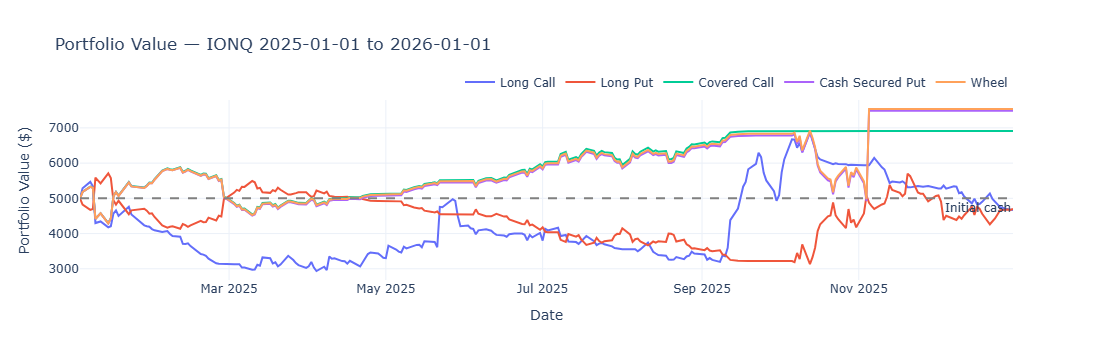

In [4]:
plot_portfolio_value(results, ticker=TICKER, start=START, end=END).show()

---
## Chart 2 — Cumulative P&L

Gain or loss relative to starting value. Easier to compare strategies directly.

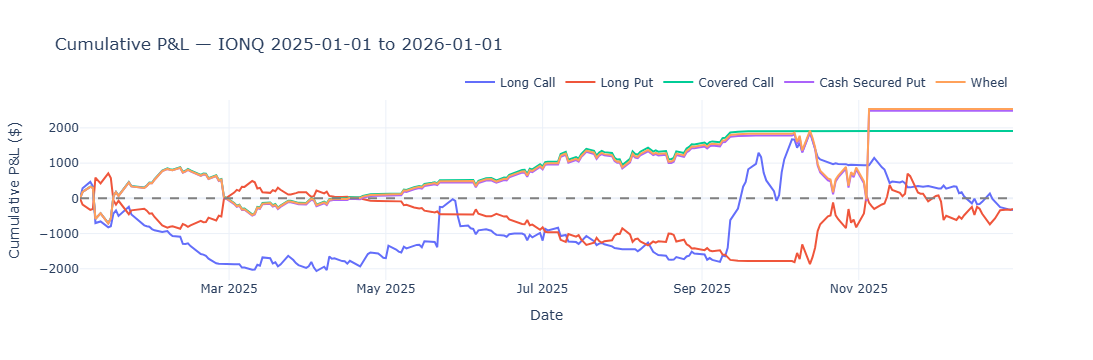

In [5]:
plot_cumulative_pnl(results, ticker=TICKER, start=START, end=END).show()

---
## Chart 3 — Daily P&L

One subplot per strategy. Green bars = profitable days, red bars = losing days.

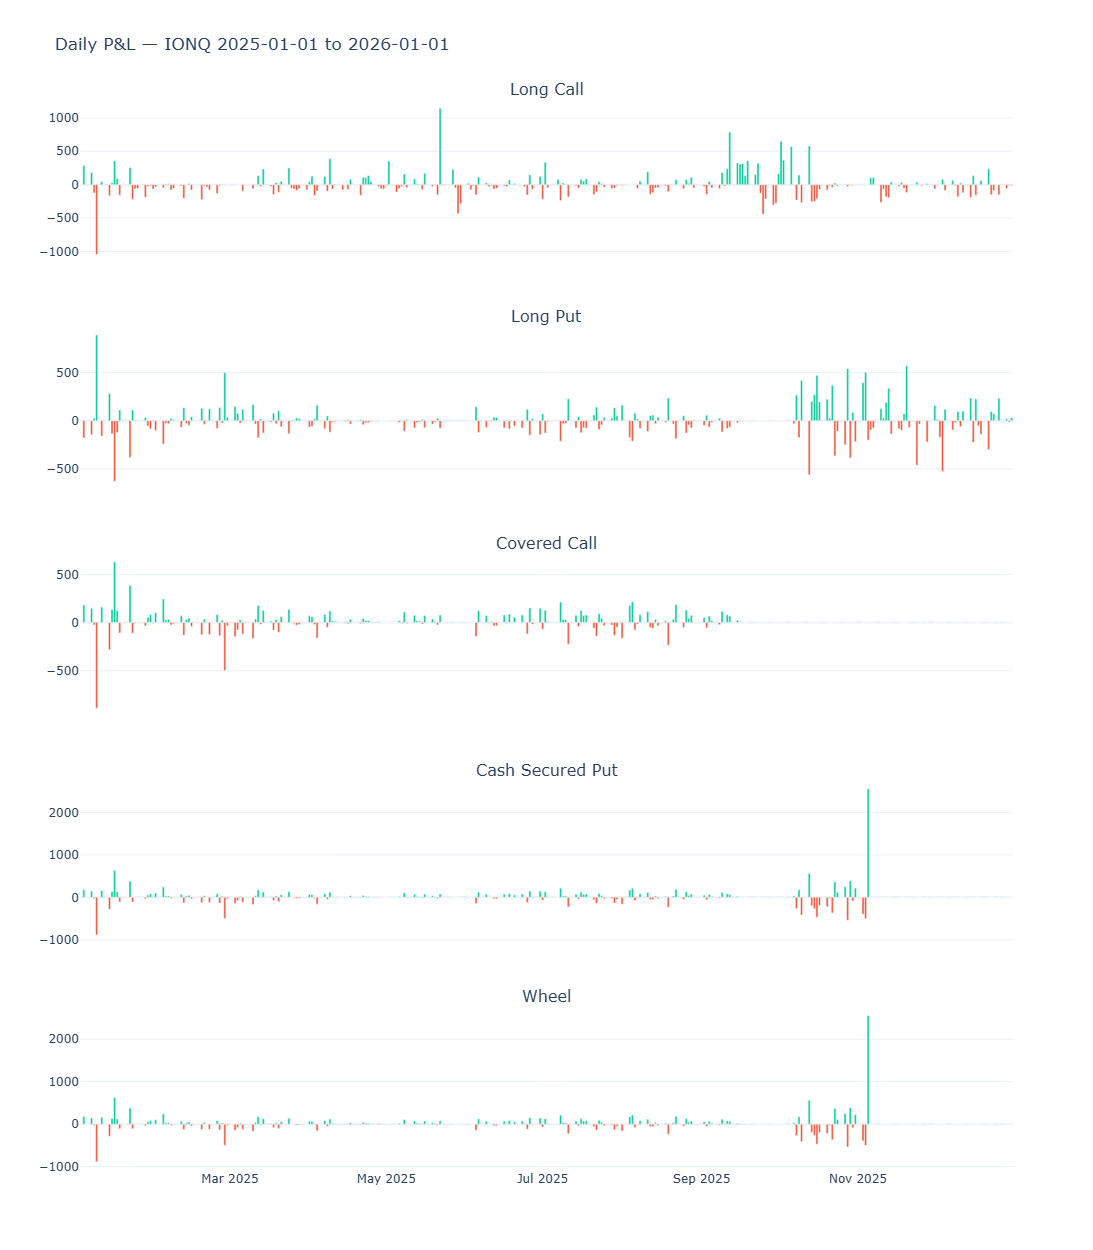

In [6]:
plot_daily_pnl(results, ticker=TICKER, start=START, end=END).show()

---
## Chart 4 — Portfolio Breakdown

Cash, stock value, and option mark-to-market stacked for a single strategy.
Change `FOCUS_STRATEGY` to inspect a different one.

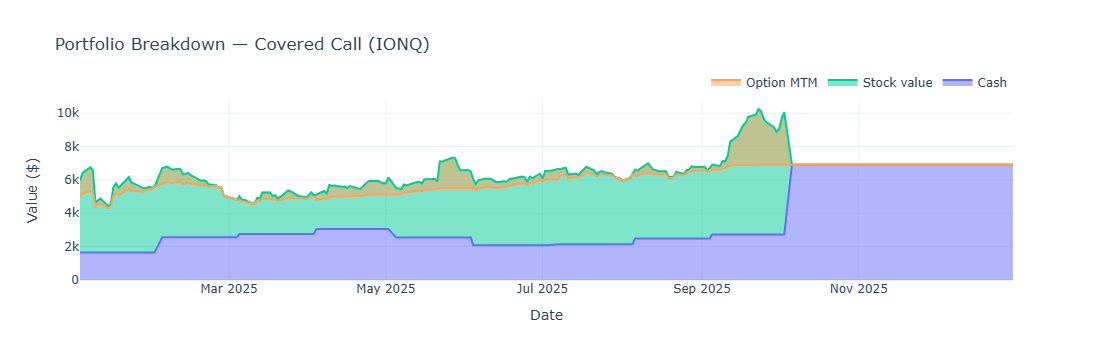

In [7]:
FOCUS_STRATEGY = "covered_call"
plot_portfolio_breakdown(results[FOCUS_STRATEGY], FOCUS_STRATEGY, ticker=TICKER).show()

---
## Summary Table

Final portfolio value, total return, and max drawdown for each strategy.

In [8]:
rows = []
for strategy, df in results.items():
    if df.empty:
        rows.append({
            "Strategy": strategy.replace("_", " ").title(),
            "Final Value ($)": "BUST",
            "Total Return": "BUST",
            "Max Drawdown": "—",
        })
    else:
        initial  = df["total_value"].iloc[0]
        final    = df["total_value"].iloc[-1]
        ret      = (final - initial) / initial
        rolling_max = df["total_value"].cummax()
        drawdown    = ((df["total_value"] - rolling_max) / rolling_max).min()
        rows.append({
            "Strategy": strategy.replace("_", " ").title(),
            "Final Value ($)": f"{final:,.2f}",
            "Total Return": f"{ret:.2%}",
            "Max Drawdown": f"{drawdown:.2%}",
        })

pd.DataFrame(rows).set_index("Strategy")

,Final Value ($),Total Return,Max Drawdown
Strategy,,,
Long Call,"4,671.81",-6.56%,-46.28%
Long Put,"4,702.17",-5.96%,-45.15%
Covered Call,"6,914.25",38.29%,-22.79%
Cash Secured Put,"7,484.81",49.70%,-28.30%
Wheel,"7,536.49",50.73%,-28.09%
